Major Project: Seasonal Agriculture Performance Analysis

VOIS AICTE Batch 1 2026-2027

Data Analytics Project

 **Problem Statement:**
 Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [3]:
df=pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4000, 28)


In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [11]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
Farm_ID,0.0
State,0.0
District,0.0
Crop,0.0
Season,0.0
Farm_Area_Hectares,0.0
Rainfall_mm,1.2
Avg_Temperature_C,0.0
Humidity_pct,0.0
Sunlight_Hours_Day,0.0


**Data Cleaning**

In [12]:
df_clean = df.copy()

In [13]:
df_clean.duplicated().sum()

np.int64(0)

In [14]:
df_clean.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [15]:
numeric_missing = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in numeric_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [16]:
df_clean.isnull().sum().sum()

np.int64(0)

**Understand categorical variables**

In [17]:
print("Seasons:")
print(df_clean['Season'].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [18]:
print("Crops:")
print(df_clean['Crop'].value_counts())

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [19]:
print("Irrigation Methods:")
print(df_clean['Irrigation_Method'].value_counts())

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [20]:
print("States:")
print(df_clean['State'].value_counts())

States:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


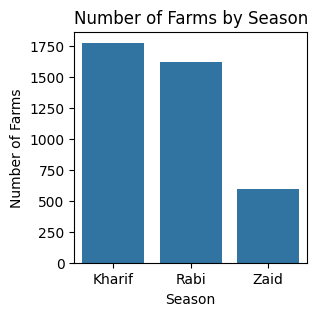

In [23]:
plt.figure(figsize=(3,3))

sns.countplot(data=df_clean, x='Season')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

In [24]:
season_summary = df_clean.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,178914.65,710719.06,531804.41,6102.20,5.89,54.47
Rabi,5.04,41.49,87689.47,601526.05,513836.58,5846.99,5.19,40.48
Zaid,4.64,38.89,-24804.82,519171.90,543976.73,6419.89,4.41,38.22


**Seasonal yield visualization**

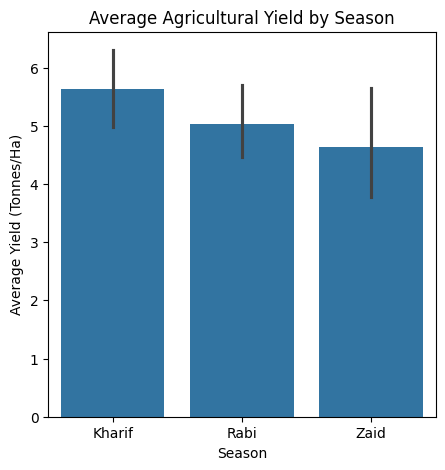

In [28]:
plt.figure(figsize=(5,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

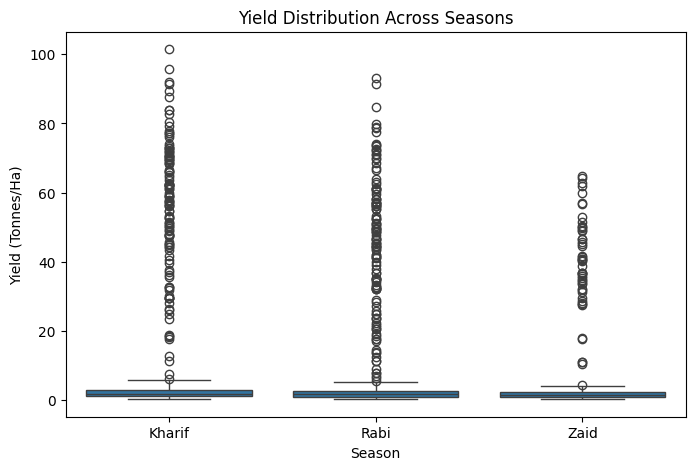

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

**Seasonal Profit**

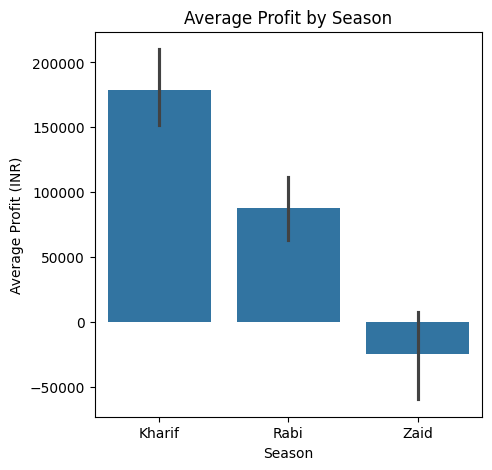

In [30]:
plt.figure(figsize=(5,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

**Crop x Season analysis**

In [31]:
crop_season = df_clean.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


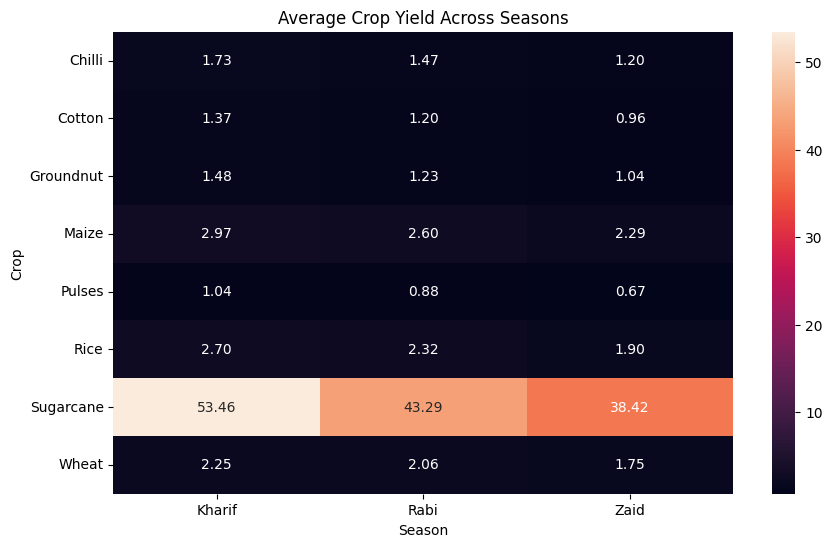

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

In [33]:
state_season = df_clean.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


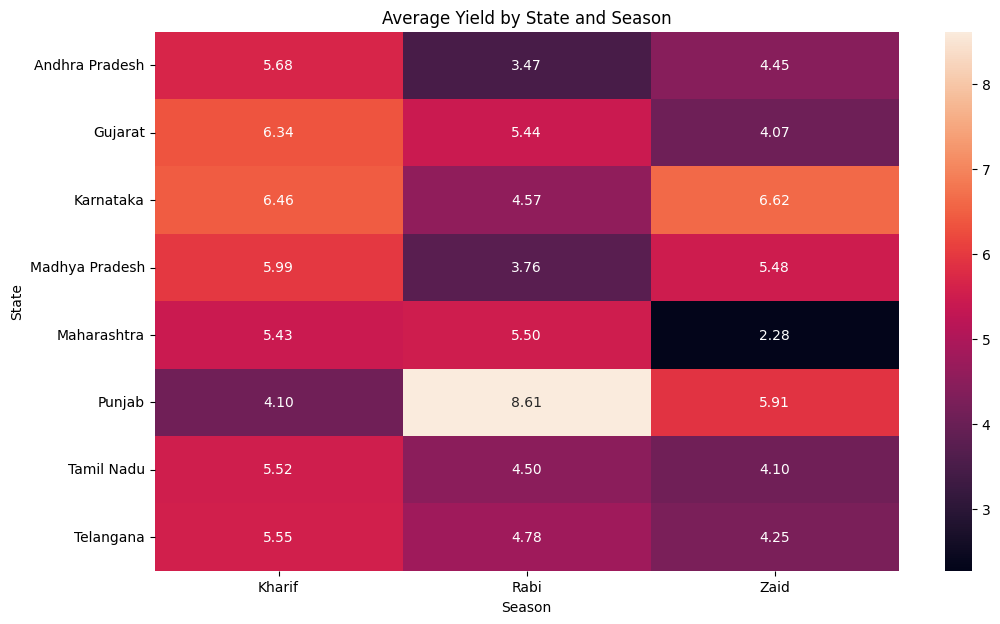

In [34]:
plt.figure(figsize=(12,7))

sns.heatmap(
    state_season,
    annot=True,
    fmt='.2f'
)

plt.title('Average Yield by State and Season')
plt.xlabel('Season')
plt.ylabel('State')

plt.show()

**Environmental Analysis**

In [35]:
environmental = df_clean.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Sunlight_Hours_Day': 'mean'
}).round(2)

environmental

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day
Season,,,,,
Kharif,849.20,28.45,71.81,31.15,6.79
Rabi,437.62,23.49,57.89,24.07,7.59
Zaid,304.65,31.04,52.01,19.28,8.18


**Irrigation Analysis**

In [36]:
irrigation_summary = df_clean.groupby(
    ['Season', 'Irrigation_Method']
).agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

irrigation_summary

Yield_Tonnes_Ha  Profit_INR  Water_Used_m3  \
Season Irrigation_Method                                               
Kharif Drip                          7.26   317222.07        5953.37   
       Flood                         4.98   133373.83        8229.27   
       Rainfed                       5.70   158974.13        3687.52   
       Sprinkler                     4.66   116880.49        5863.27   
Rabi   Drip                          6.11   187843.22        5911.41   
       Flood                         5.06    58824.80        7766.83   
       Rainfed                       3.93    45232.48        3298.29   
       Sprinkler                     5.31    76502.07        6129.09   
Zaid   Drip                          5.85    21291.84        5837.99   
       Flood                         3.98   -69786.78        8113.69   
       Rainfed                       3.06   -79467.26        3879.39   
       Sprinkler                     6.14    57909.40        7324.41   

                          Water_Efficiency_t_per_1000m3  
Season Irrigation_Method                                 
Kharif Drip                                        6.80  
       Flood                                       3.64  
       Rainfed                                     8.85  
       Sprinkler                                   4.62  
Rabi   Drip                                        6.05  
       Flood                                       3.48  
       Rainfed                                     6.87  
       Sprinkler                                   4.64  
Zaid   Drip                                        5.30  
       Flood                                       2.73  
       Rainfed                                     5.48  
       Sprinkler                                   4.86

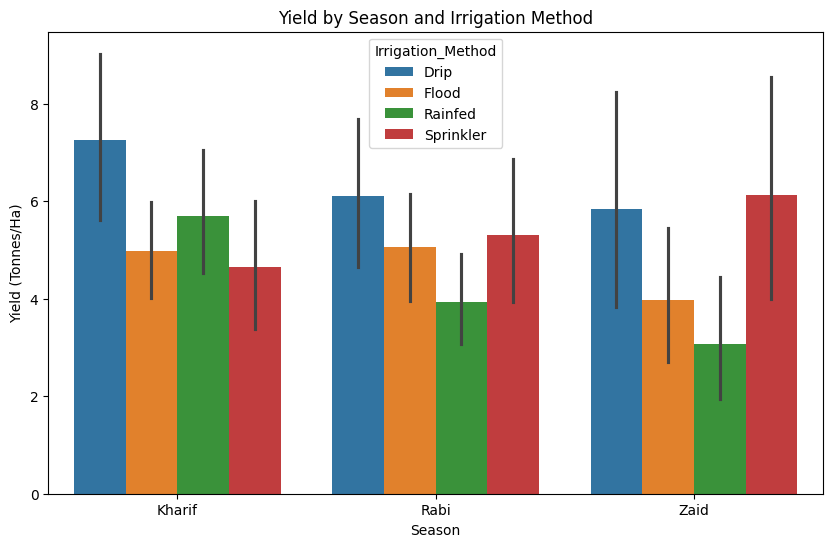

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    hue='Irrigation_Method'
)

plt.title('Yield by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

**Water Efficiency**

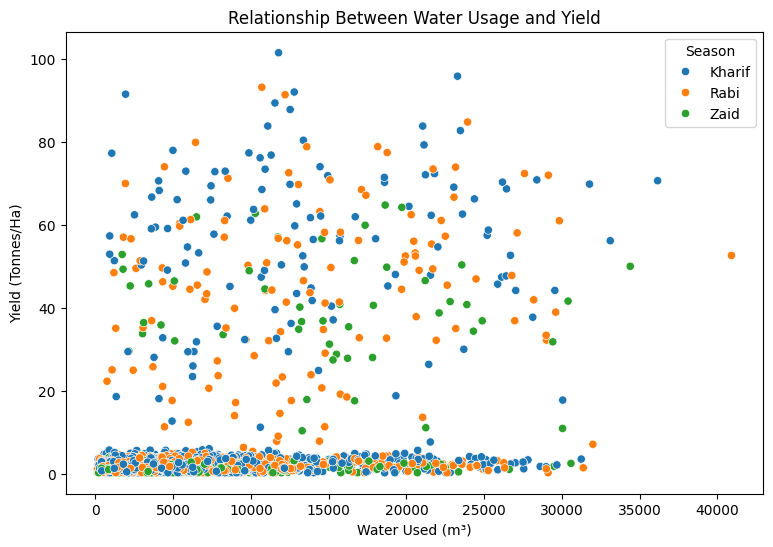

In [38]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_clean,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Relationship Between Water Usage and Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [39]:
df_clean.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().round(2)

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.89
Rabi,5.19
Zaid,4.41


**Economic analysis**

In [40]:
economic_summary = df_clean.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

economic_summary

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


In [41]:
df_clean['Profitable'] = df_clean['Profit_INR'] > 0

profitability = (
    df_clean.groupby('Season')['Profitable']
    .mean() * 100
)

profitability.round(2)

,Profitable
Season,
Kharif,57.79
Rabi,48.86
Zaid,35.52


**Correlation Analysis**

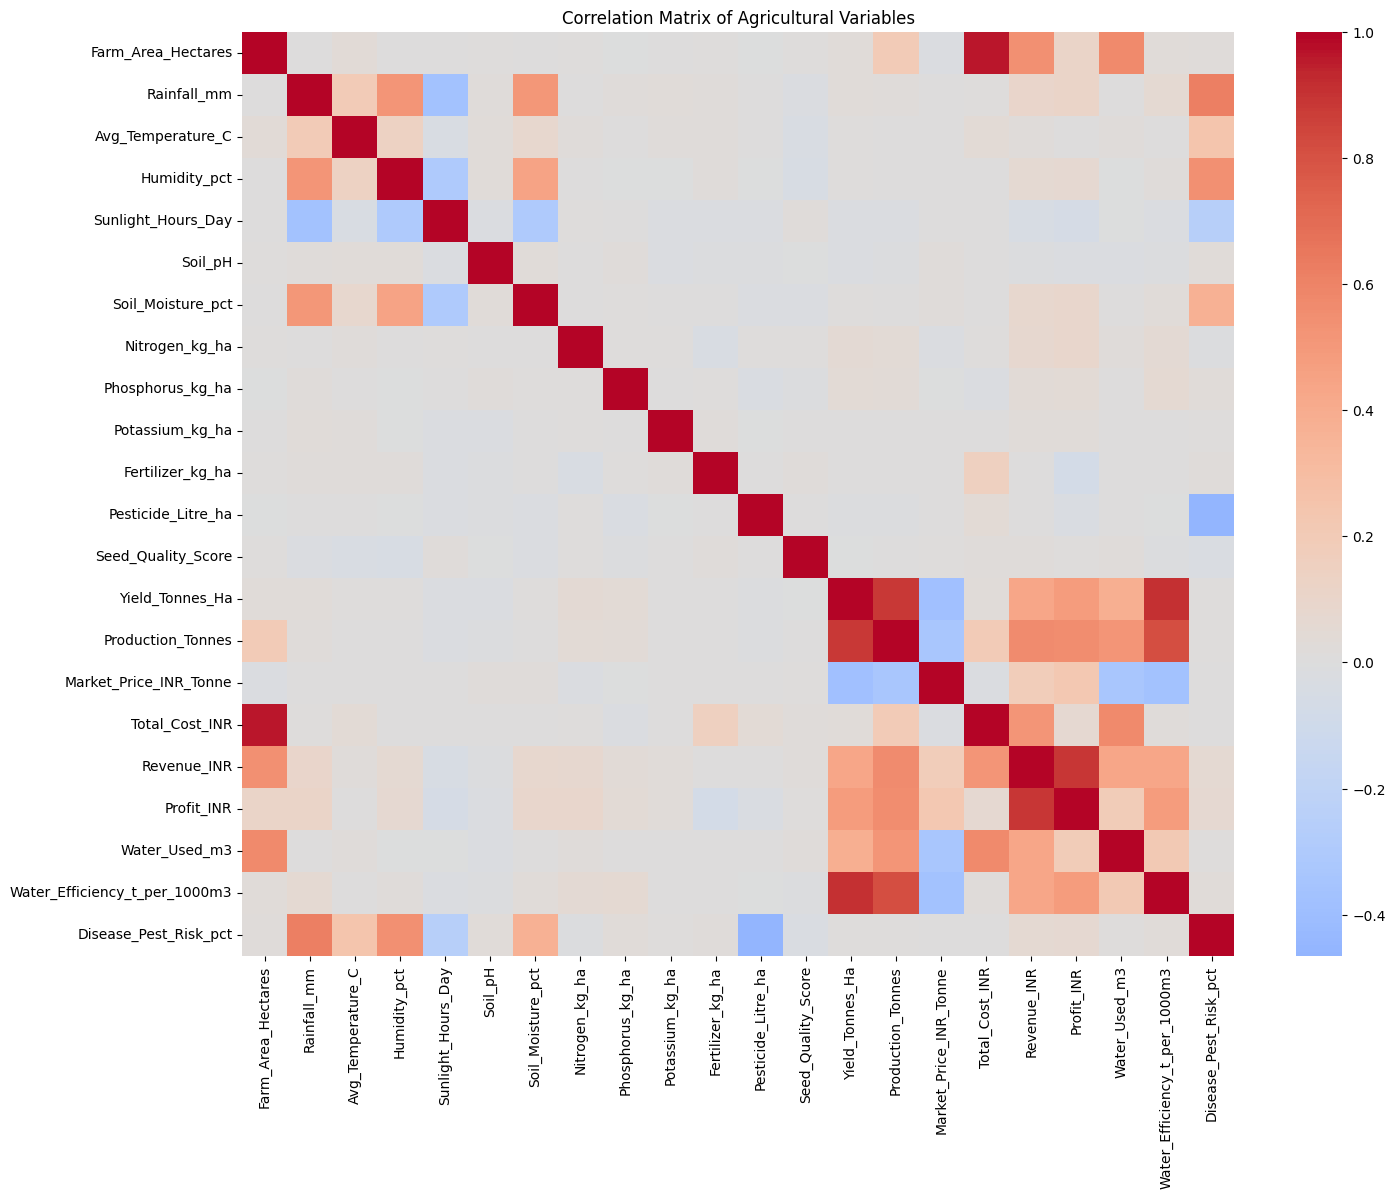

In [42]:
numeric_cols = df_clean.select_dtypes(
    include=np.number
).columns

correlation = df_clean[numeric_cols].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.show()

**Statistical hypothesis testing**

In [43]:
kharif = df_clean[
    df_clean['Season'] == 'Kharif'
]['Yield_Tonnes_Ha']

rabi = df_clean[
    df_clean['Season'] == 'Rabi'
]['Yield_Tonnes_Ha']

zaid = df_clean[
    df_clean['Season'] == 'Zaid'
]['Yield_Tonnes_Ha']

anova_result = stats.f_oneway(
    kharif,
    rabi,
    zaid
)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [44]:
df_clean.nlargest(
    10, 'Profit_INR'
)[['Farm_ID', 'Season', 'Crop', 'Profit_INR']]

,Farm_ID,Season,Crop,Profit_INR
2236,SF12237,Kharif,Chilli,4345421
626,SF10627,Kharif,Chilli,4021850
3425,SF13426,Kharif,Sugarcane,3740099
1690,SF11691,Kharif,Chilli,3738329
247,SF10248,Kharif,Chilli,3542204
357,SF10358,Rabi,Sugarcane,3378879
3423,SF13424,Kharif,Sugarcane,3330582
1930,SF11931,Kharif,Sugarcane,3232970
3983,SF13984,Kharif,Chilli,3211345
263,SF10264,Rabi,Chilli,3159447


In [45]:
df_clean.nsmallest(
    10, 'Profit_INR'
)[['Farm_ID', 'Season', 'Crop', 'Profit_INR']]

,Farm_ID,Season,Crop,Profit_INR
780,SF10781,Rabi,Groundnut,-1019223
2210,SF12211,Rabi,Wheat,-995195
3625,SF13626,Rabi,Maize,-981050
2182,SF12183,Kharif,Rice,-976860
104,SF10105,Zaid,Wheat,-965197
3394,SF13395,Kharif,Wheat,-963396
2730,SF12731,Rabi,Rice,-906082
1311,SF11312,Zaid,Rice,-902740
585,SF10586,Zaid,Cotton,-895730
3090,SF13091,Kharif,Maize,-890641


**Fertilizer Usage Analysis**

In [47]:
df_clean['Fertilizer_kg_ha'].describe()

,Fertilizer_kg_ha
count,4000.000000
mean,186.036000
std,60.260583
min,40.000000
25%,143.975000
50%,186.250000
75%,227.200000
max,400.000000


In [49]:
fertilizer_season = df_clean.groupby(
    'Season'
)['Fertilizer_kg_ha'].mean().sort_values(ascending=False)

print(fertilizer_season.round(2))

Season
Kharif    187.08
Rabi      185.41
Zaid      184.64
Name: Fertilizer_kg_ha, dtype: float64


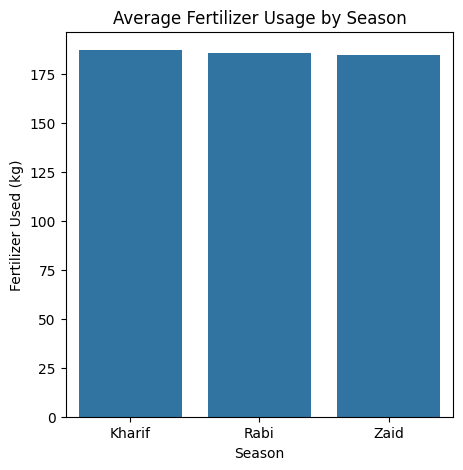

In [53]:
plt.figure(figsize=(5,5))

sns.barplot(
    x=fertilizer_season.index,
    y=fertilizer_season.values
)

plt.title('Average Fertilizer Usage by Season')
plt.xlabel('Season')
plt.ylabel('Fertilizer Used (kg)')

plt.show()

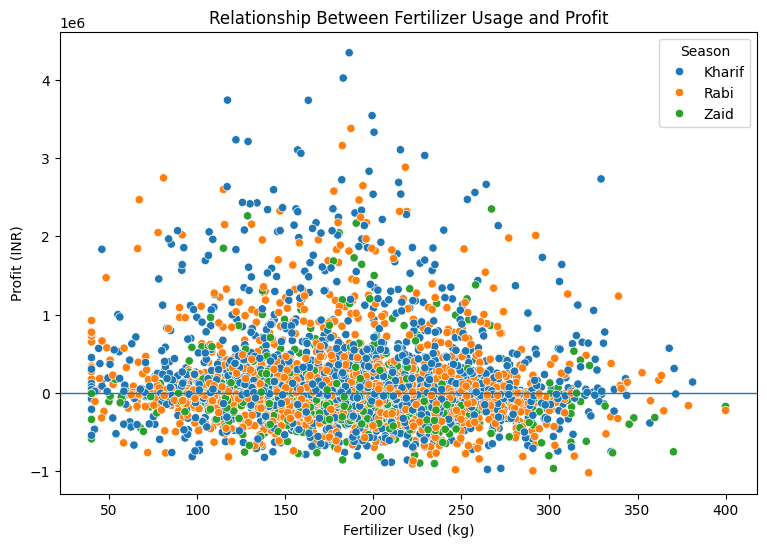

In [55]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_clean,
    x='Fertilizer_kg_ha',
    y='Profit_INR',
    hue='Season'
)

plt.title('Relationship Between Fertilizer Usage and Profit')
plt.xlabel('Fertilizer Used (kg)')
plt.ylabel('Profit (INR)')

plt.axhline(0, linewidth=1)

plt.show()

In [57]:
fertilizer_profit_corr = df_clean[
    'Fertilizer_kg_ha'
].corr(
    df_clean['Profit_INR']
)

print(
    "Correlation between Fertilizer Usage and Profit:",
    round(fertilizer_profit_corr, 3)
)

Correlation between Fertilizer Usage and Profit: -0.074


**Soil Moisture Analysis**

In [58]:
df_clean['Soil_Moisture_pct'].describe()

,Soil_Moisture_pct
count,4000.000000
mean,26.507150
std,6.678837
min,8.000000
25%,21.800000
50%,26.400000
75%,31.200000
max,47.000000


In [59]:
soil_moisture_season = df_clean.groupby(
    'Season'
)['Soil_Moisture_pct'].mean().sort_values(ascending=False)

print(soil_moisture_season.round(2))

Season
Kharif    31.15
Rabi      24.07
Zaid      19.28
Name: Soil_Moisture_pct, dtype: float64


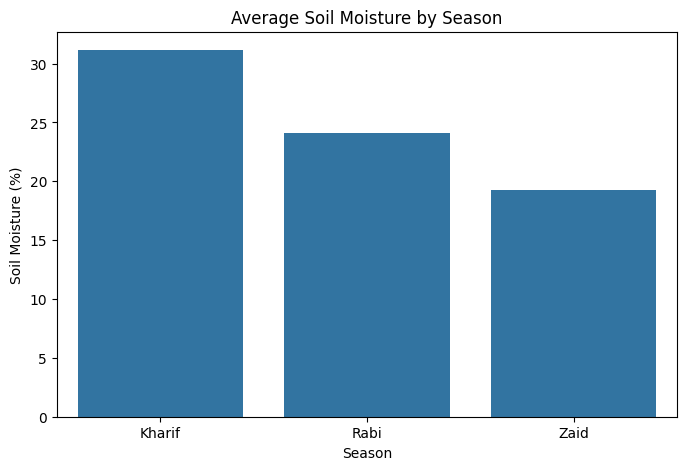

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=soil_moisture_season.index,
    y=soil_moisture_season.values
)

plt.title('Average Soil Moisture by Season')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')

plt.show()

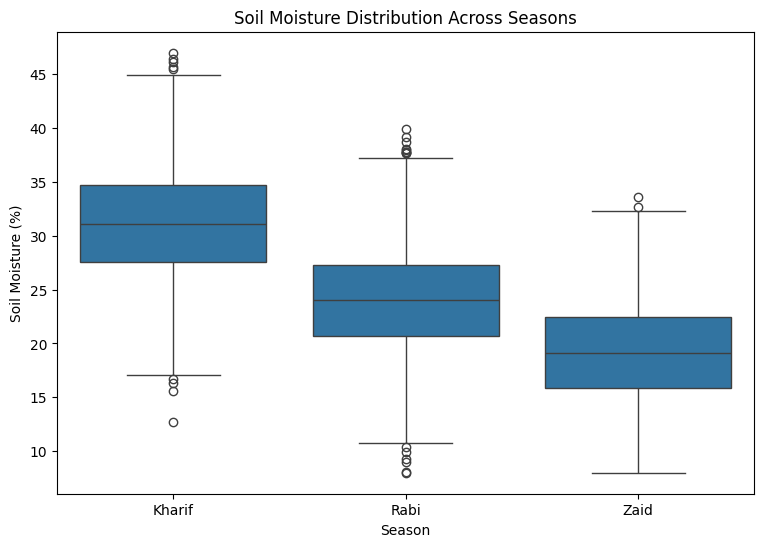

In [61]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Soil_Moisture_pct'
)

plt.title('Soil Moisture Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')

plt.show()

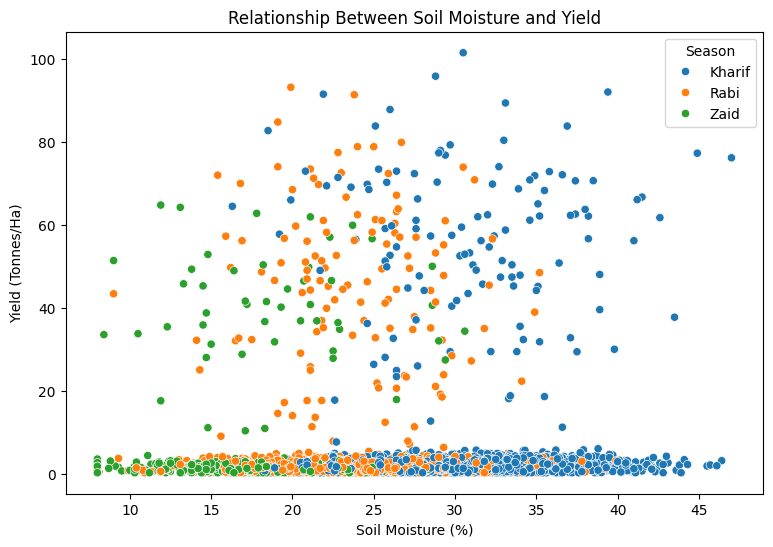

In [62]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_clean,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Relationship Between Soil Moisture and Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [63]:
soil_yield_corr = df_clean[
    'Soil_Moisture_pct'
].corr(
    df_clean['Yield_Tonnes_Ha']
)

print(
    "Correlation between Soil Moisture and Yield:",
    round(soil_yield_corr, 3)
)

Correlation between Soil Moisture and Yield: 0.011
